<a href="https://colab.research.google.com/github/ashik7555-netizen/Python-Basics-Case-Study/blob/main/Unsupervised_casestudyyy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
data = pd.read_csv('/content/adult_dataset.csv')
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [6]:
data.shape

(48842, 15)

In [7]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [8]:
data.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [9]:
data.isna().mean()*100

,0
age,4.999795
workclass,6.883420
fnlwgt,0.000000
education,0.000000
education-num,0.000000
marital-status,0.000000
occupation,6.873183
relationship,0.000000
race,0.000000
sex,0.000000


In [10]:
data.duplicated().sum()

np.int64(16)

In [11]:
(data == '?').sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [12]:
data = data.replace('?', np.nan)

In [13]:
data.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


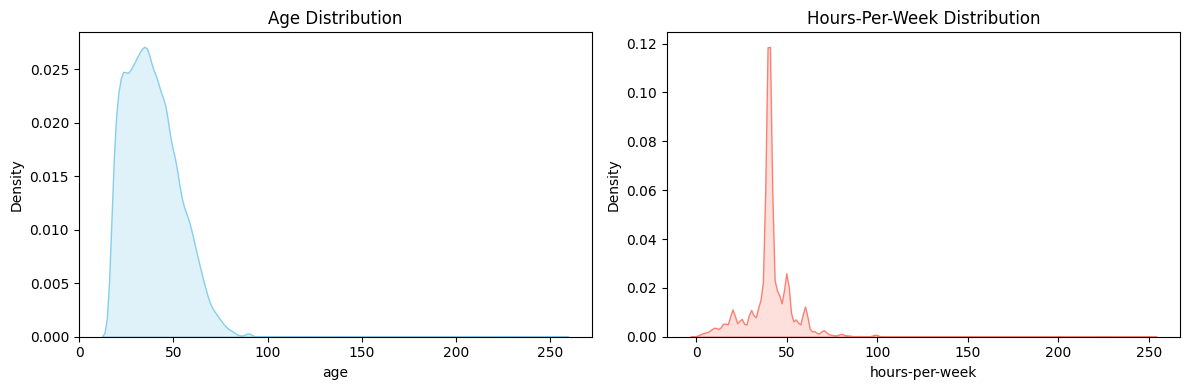

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data['age'].dropna(), ax=axes[0], fill=True, color='skyblue')
axes[0].set_title('Age Distribution')

sns.kdeplot(data['hours-per-week'].dropna(), ax=axes[1], fill=True, color='salmon')
axes[1].set_title('Hours-Per-Week Distribution')

plt.tight_layout()
plt.show()

In [15]:
data['age'] = data['age'].fillna(data['age'].median())
data['hours-per-week'] = data['hours-per-week'].fillna(data['hours-per-week'].median())

categorical_cols = ['workclass', 'occupation', 'native-country']
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [16]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


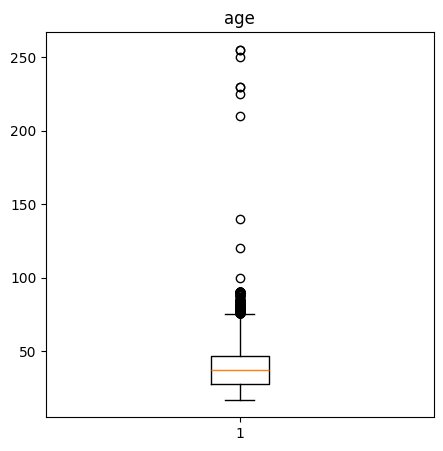

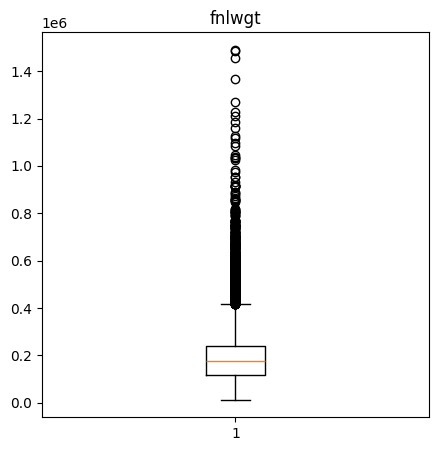

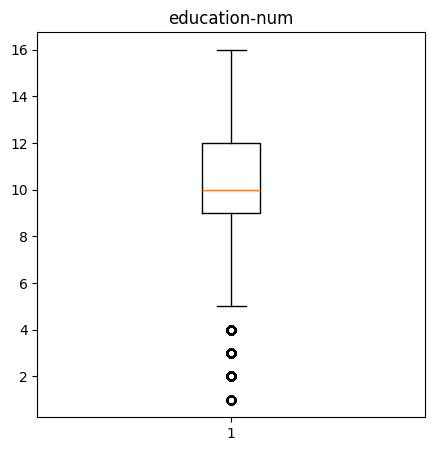

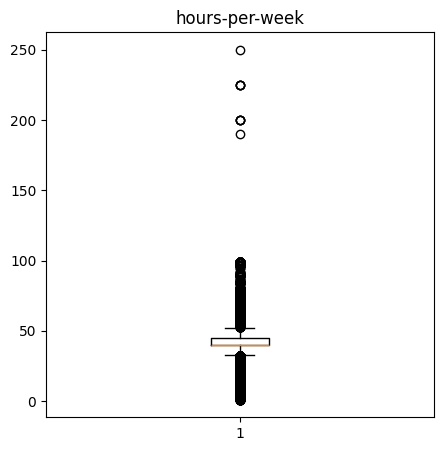

In [17]:
numeric_columns = ['age', 'fnlwgt', 'education-num', 'hours-per-week']
for i in numeric_columns:
  plt.figure(figsize = (5,5))
  plt.boxplot(data[i])  #drawing boxplot to check the presence of extreme values
  plt.title(i)

In [18]:
for i in numeric_columns:
  q1 = data[i].quantile(0.25)
  q3 = data[i].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  data[i] = data[i].clip(lower = lower_bound, upper = upper_bound)

print("Outliers are removed")

Outliers are removed


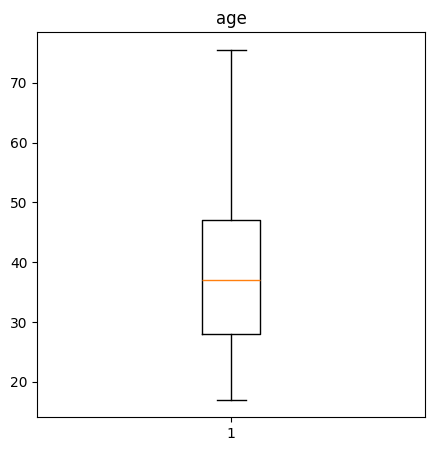

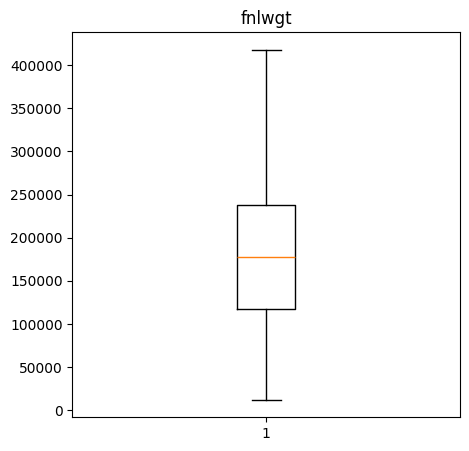

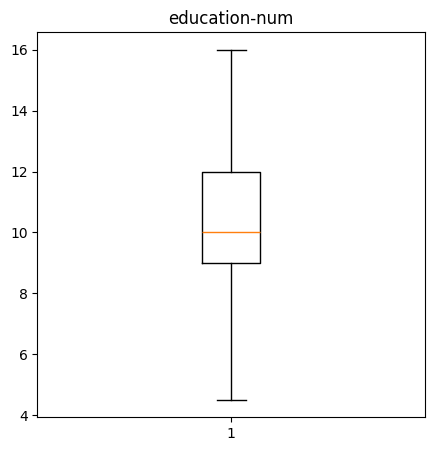

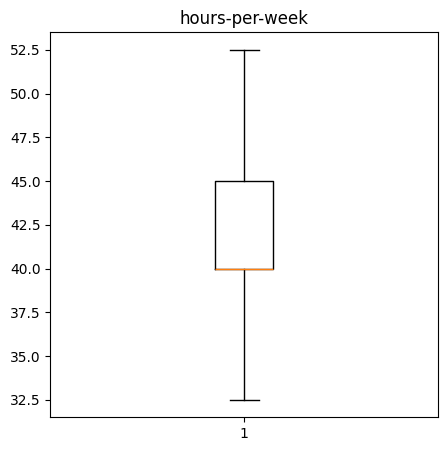

In [19]:
for i in numeric_columns:
  plt.figure(figsize = (5,5))
  plt.boxplot(data[i])
  plt.title(i)

In [20]:
data['sex'] = data['sex'].map({'Male': 1, 'Female': 0})
data['income'] = data['income'].astype(str).str.strip('. ').map({'<=50K': 0, '>50K': 1})
categorical_cols = ['education', 'workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True, dtype=int)
print("New shape:", data.shape)
data.head()

New shape: (48842, 98)


,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,education_11th,education_12th,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,77516.0,13.0,1,2174,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,83311.0,13.0,1,0,0,32.5,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,215646.0,9.0,1,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,234721.0,7.0,1,0,0,40.0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,338409.0,13.0,0,0,0,40.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
data[data.columns] = scaler.fit_transform(data[data.columns])
data.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,education_11th,education_12th,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.035311,-1.146097,1.171374,0.70422,0.146932,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.036785,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705
1,0.864184,-1.085307,1.171374,0.70422,-0.144804,-0.217127,-1.430298,-0.560845,-0.196287,-0.116769,...,-0.036785,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705
2,-0.040041,0.302906,-0.456714,0.70422,-0.144804,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.036785,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705
3,1.090241,0.503005,-1.270758,0.70422,-0.144804,-0.217127,-0.187236,-0.560845,5.094580,-0.116769,...,-0.036785,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705
4,-0.793562,1.590706,1.171374,-1.42001,-0.144804,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.036785,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,-3.366577,-0.041258,-0.021705


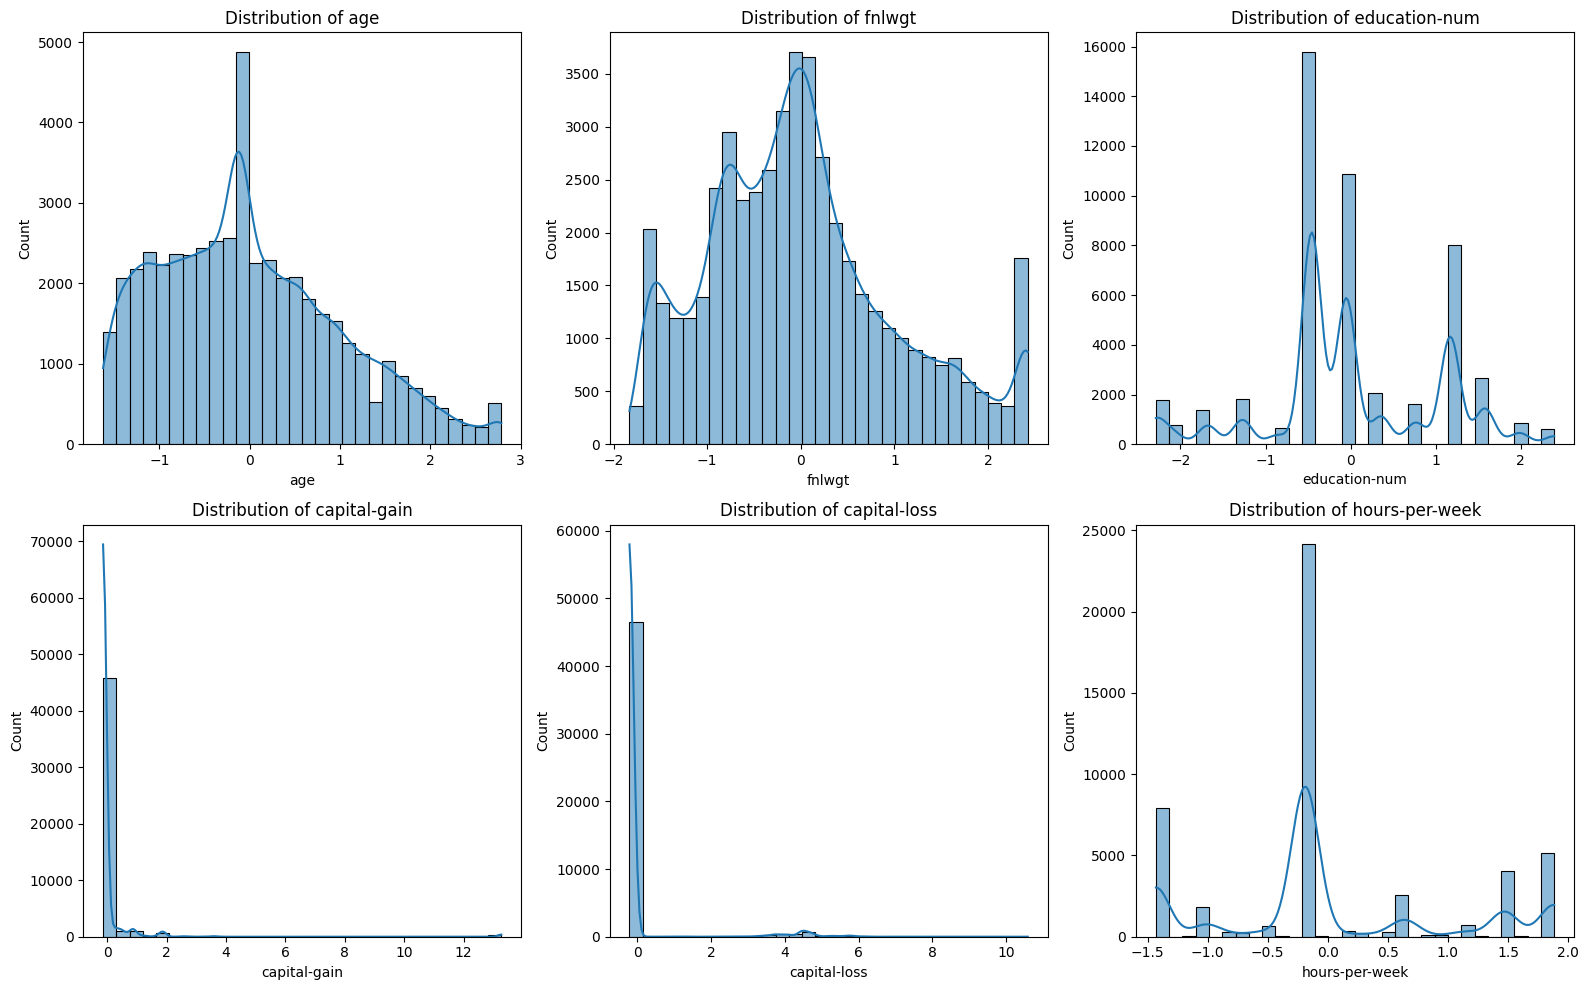

In [23]:
continuous_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

plt.figure(figsize=(16,10 ))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2208/397065968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


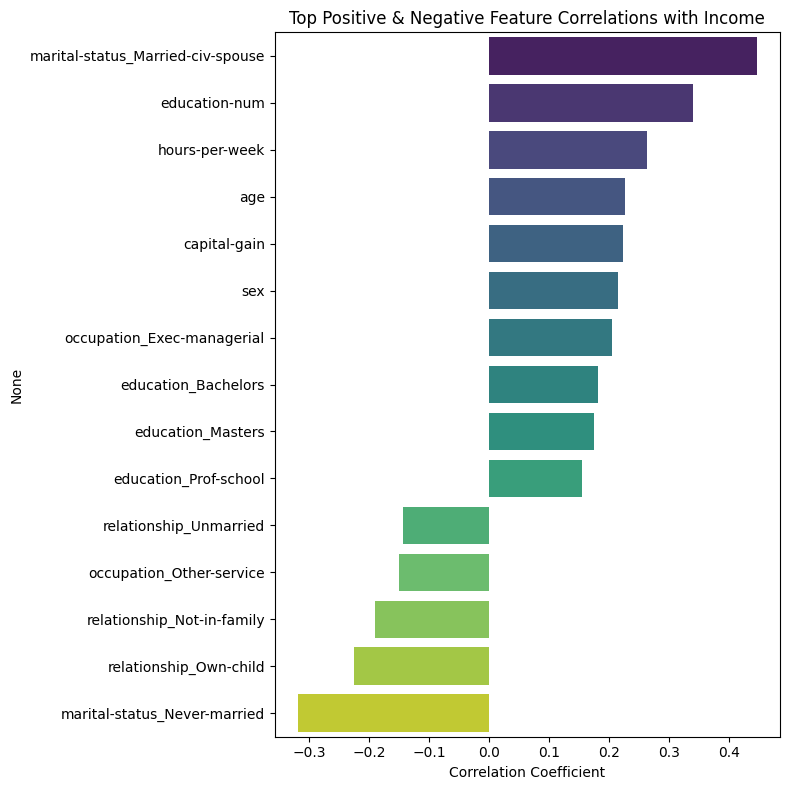

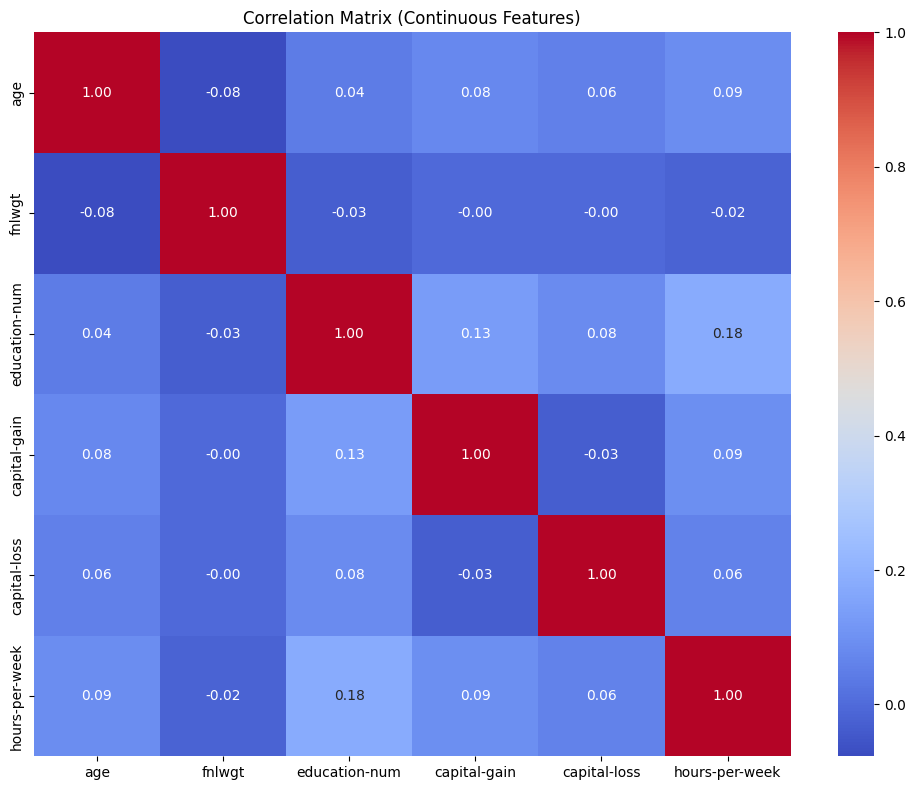

In [24]:
if 'income' in data.columns:
    plt.figure(figsize=(8,8))
    income_corr = data.corr()['income'].sort_values(ascending=False).drop('income')
    top_corr = pd.concat([income_corr.head(10), income_corr.tail(5)])

    sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
    plt.title('Top Positive & Negative Feature Correlations with Income')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(data[continuous_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Continuous Features)')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.decomposition import PCA

Explained Variance Ratio (PC1 & PC2): [0.03549675 0.02729568]
Total Variance Retained: 6.28%


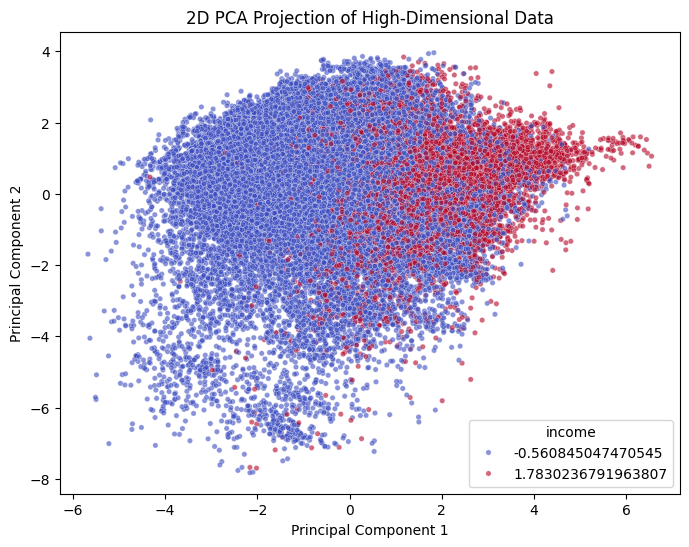

In [26]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(data.drop(columns=['income']) if 'income' in data.columns else data)

print(f"Explained Variance Ratio (PC1 & PC2): {pca.explained_variance_ratio_}")
print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_results[:, 0], y=pca_results[:, 1],
    hue=data['income'] if 'income' in data.columns else None,
    palette='coolwarm', alpha=0.6, s=15
)
plt.title('2D PCA Projection of High-Dimensional Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

3


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [28]:
wcss_list = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
  kmeans.fit(data)
  wcss_list.append(kmeans.inertia_)

wcss_list

[4786516.0,
 4737481.376443508,
 4597940.448690946,
 4549833.094456413,
 4504638.675606699,
 4434372.891884307,
 4385048.01417922,
 4307095.443408826,
 4255382.528334369,
 4205608.220854291]

Text(0, 0.5, 'WCSS')

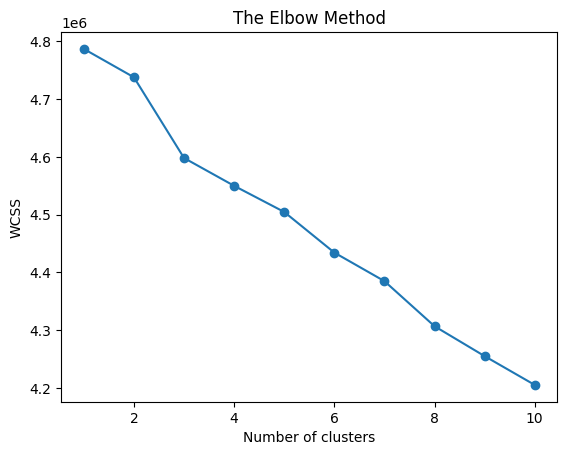

In [29]:
plt.plot(range(1, 11), wcss_list, marker = 'o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [30]:
from sklearn.metrics import silhouette_score


sample_df = data.sample(n=5000, random_state=42)
X_sample = sample_df.drop(columns=['kmeans_cluster', 'income'], errors='ignore')

for k in range(2, 7):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    print(f"For K = {k}, Silhouette Score = {score:.4f}")

For K = 2, Silhouette Score = 0.0605
For K = 3, Silhouette Score = 0.0621
For K = 4, Silhouette Score = 0.0471
For K = 5, Silhouette Score = 0.0314
For K = 6, Silhouette Score = 0.0511


In [31]:
kmeans_model = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42, n_init = 10)
y_predict = kmeans_model.fit_predict(data)
y_predict

array([3, 3, 1, ..., 3, 2, 3], dtype=int32)

4.


In [32]:
data['kmeans_cluster'] = y_predict
data.head()


,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,education_11th,education_12th,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,kmeans_cluster
0,0.035311,-1.146097,1.171374,0.70422,0.146932,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705,3
1,0.864184,-1.085307,1.171374,0.70422,-0.144804,-0.217127,-1.430298,-0.560845,-0.196287,-0.116769,...,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705,3
2,-0.040041,0.302906,-0.456714,0.70422,-0.144804,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705,1
3,1.090241,0.503005,-1.270758,0.70422,-0.144804,-0.217127,-0.187236,-0.560845,5.094580,-0.116769,...,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,0.297038,-0.041258,-0.021705,1
4,-0.793562,1.590706,1.171374,-1.42001,-0.144804,-0.217127,-0.187236,-0.560845,-0.196287,-0.116769,...,-0.059966,-0.02024,-0.046637,-0.035362,-0.024374,-0.02263,-3.366577,-0.041258,-0.021705,3


In [33]:
data.shape

(48842, 99)

In [34]:
data['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
1,21125
0,15109
3,10977
2,1585
4,46


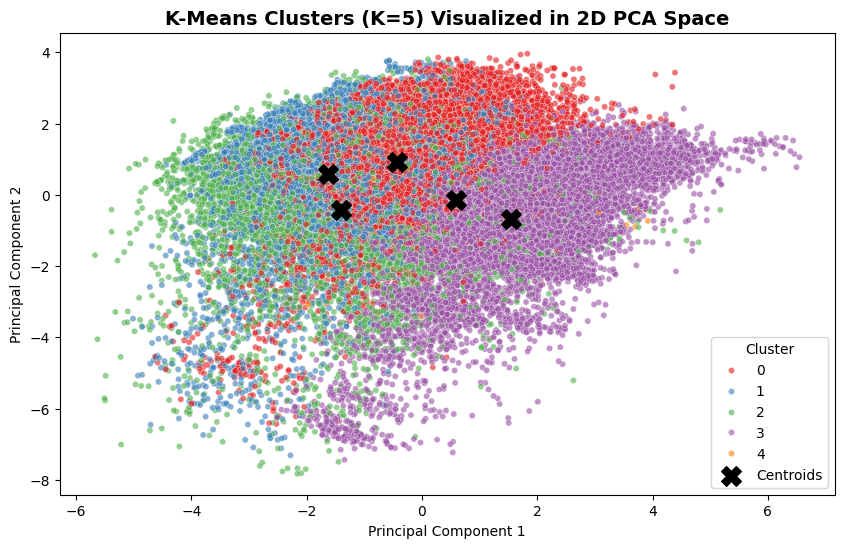

In [35]:
from sklearn.decomposition import PCA

X_features = data.drop(columns=['income', 'kmeans_cluster'], errors='ignore')

kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
data['kmeans_cluster'] = kmeans_model.fit_predict(X_features)

pca = PCA(n_components=2)
pca_2d = pca.fit_transform(X_features)

centroids_df = pd.DataFrame(kmeans_model.cluster_centers_, columns=X_features.columns)
centroids_2d = pca.transform(centroids_df)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_2d[:, 0],
    y=pca_2d[:, 1],
    hue=data['kmeans_cluster'],
    palette='Set1',
    alpha=0.6,
    s=20
)

plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title('K-Means Clusters (K=5) Visualized in 2D PCA Space', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

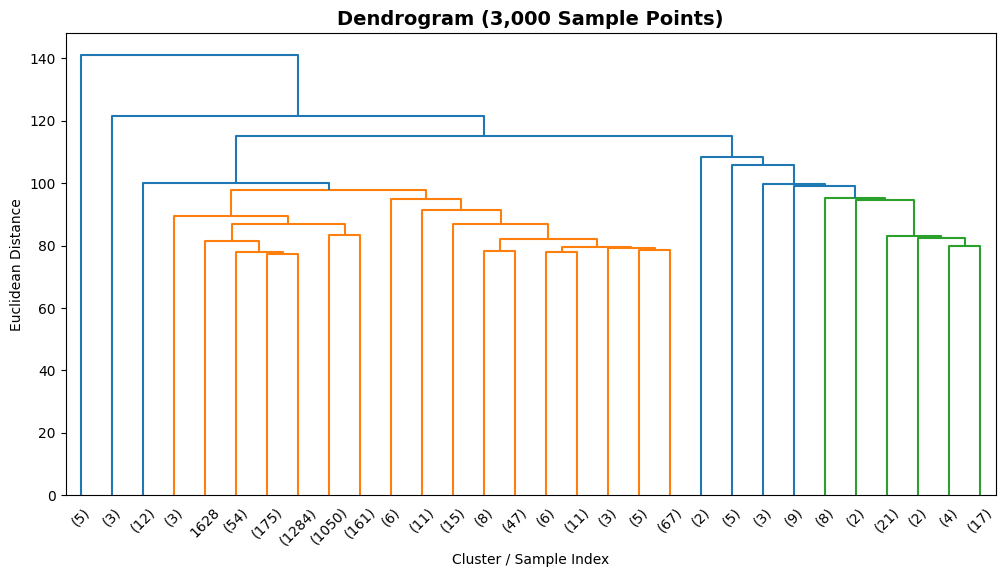

In [36]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

sample_data = X_features.sample(n=3000, random_state=42)

mergings = sch.linkage(sample_data, method='ward')

plt.figure(figsize=(12, 6))
sch.dendrogram(mergings, truncate_mode='lastp', p=30)  # Truncates tree view for clean reading
plt.title('Dendrogram (3,000 Sample Points)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster / Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()

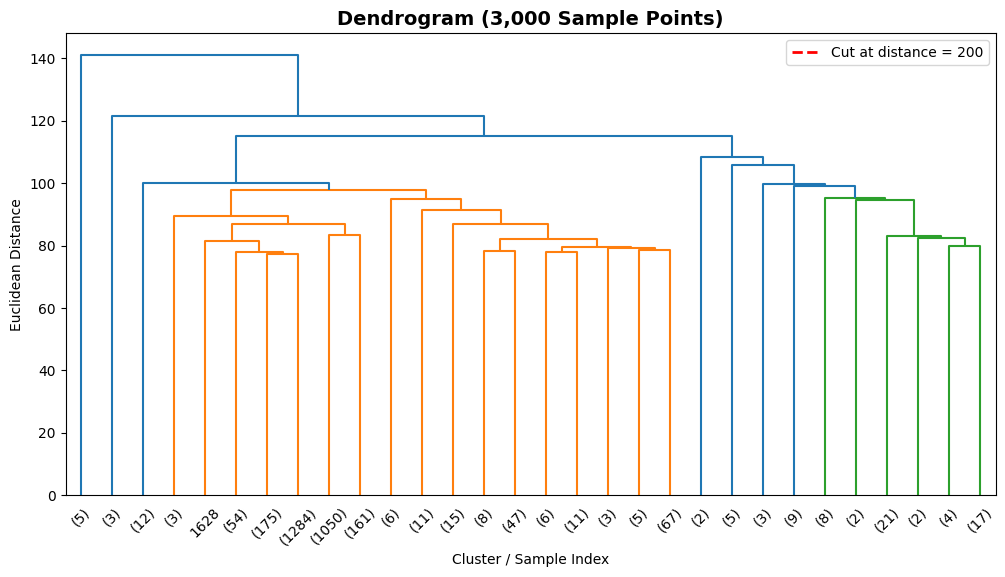

In [37]:
plt.figure(figsize=(12, 6))
sch.dendrogram(mergings, truncate_mode='lastp', p=30)

# Draw the cut line
plt.axhline(y=200, color='red', linestyle='--', linewidth=2,
            label='Cut at distance = 200')

plt.title('Dendrogram (3,000 Sample Points)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster / Sample Index')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.show()

In [39]:
from scipy.cluster.hierarchy import fcluster

sample_data['agglo_cluster'] = fcluster(mergings, t=5, criterion='maxclust')


print(sample_data['agglo_cluster'].value_counts())

agglo_cluster
3    2919
5      71
1       5
2       3
4       2
Name: count, dtype: int64


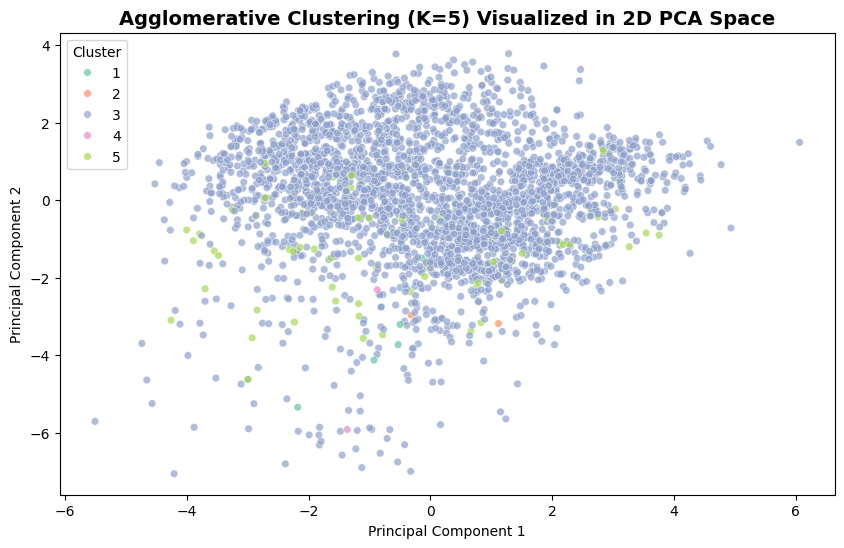

In [43]:


X_sample_features = sample_data.drop(columns=['agglo_cluster'], errors='ignore')


pca_agg_2d = pca.transform(X_sample_features)


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pca_agg_2d[:, 0],
    y=pca_agg_2d[:, 1],
    hue=sample_data['agglo_cluster'],
    palette='Set2',
    alpha=0.7,
    s=30
)

plt.title('Agglomerative Clustering (K=5) Visualized in 2D PCA Space', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [44]:
kmeans_profile = data.groupby('kmeans_cluster').mean(numeric_only=True)
display(kmeans_profile)

agg_profile = sample_data.groupby('agglo_cluster').mean(numeric_only=True)
display(agg_profile)

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,education_11th,education_12th,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.010903,-0.016914,0.127115,-0.292871,-0.041280,-0.021162,0.014966,-0.312409,-0.079292,-0.039829,...,-0.021861,-0.001854,-0.002174,-0.046637,-0.035362,-0.024374,-0.022630,0.100533,-0.041258,-0.004859
1,-0.617823,0.000962,-0.275105,-0.468669,-0.119332,-0.118152,-0.448579,-0.504765,0.188859,0.090927,...,0.008480,0.012700,0.002591,-0.044652,-0.035362,-0.016790,-0.022630,0.037793,-0.041258,-0.004673
2,-0.069264,0.195006,-0.122507,-0.258593,-0.037645,-0.046916,-0.185543,-0.205187,0.047845,0.063149,...,-0.028548,0.048908,-0.012762,0.294716,-0.035362,0.137098,0.144585,-0.442336,0.263604,-0.021705
3,0.357077,-0.054584,0.113609,0.489319,0.097255,0.088930,0.290110,0.500686,-0.072586,-0.046990,...,0.016586,-0.021410,0.003987,-0.046637,-0.035362,-0.022362,-0.022630,0.079397,-0.041258,0.012183
4,-0.327862,-0.011129,1.291479,0.077398,0.133832,0.104070,-0.005191,0.399757,-0.196287,-0.116769,...,-0.036785,-0.059966,-0.020240,-0.046637,28.278765,-0.024374,-0.022630,-3.366577,-0.041258,-0.021705


,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,education_11th,education_12th,education_1st-4th,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
agglo_cluster,,,,,,,,,,,,,,,,,,,,,
1,0.773762,0.757910,-0.700928,0.279374,-0.144804,0.719348,0.160822,-0.196287,-0.116769,-0.071294,...,-0.036785,-0.059966,-0.020240,-0.046637,-0.035362,-0.024374,44.189139,-3.366577,-0.041258,-0.021705
2,0.462306,0.114485,-0.321040,-0.003856,-0.144804,-0.217127,-0.187236,-0.196287,-0.116769,-0.071294,...,-0.036785,-0.059966,49.407489,-0.046637,-0.035362,-0.024374,-0.022630,-3.366577,-0.041258,-0.021705
3,-0.015724,-0.016582,-0.000540,-0.005312,-0.001673,-0.024302,0.013227,0.008532,0.031924,-0.013338,...,0.019170,0.003103,-0.020240,-0.024551,-0.035362,-0.024374,-0.022630,0.092458,-0.041258,-0.021705
4,0.449748,0.931018,-1.372514,-1.420010,-0.144804,-0.217127,-1.057379,-0.196287,-0.116769,-0.071294,...,-0.036785,-0.059966,-0.020240,-0.046637,-0.035362,-0.024374,-0.022630,-3.366577,-0.041258,-0.021705
5,-0.140864,0.029822,0.629633,-0.073667,-0.097305,0.052750,-0.258434,-0.121768,-0.116769,-0.071294,...,-0.036785,-0.059966,-0.020240,-0.046637,1.559800,1.132000,-0.022630,-3.366577,2.694380,-0.021705


In [45]:
pd.crosstab(
    data['kmeans_cluster'],
    data['income'],
    normalize='index'
) * 100

income,-0.560845,1.783024
kmeans_cluster,,
0,89.400585,10.599415
1,97.607390,2.392610
2,84.826021,15.173979
3,54.710323,45.289677
4,59.016393,40.983607
